## Correspondance avec les livrables (§9 du sujet)

| Livrable | Fichier / dossier |
|----------|-------------------|
| 1. Rapport scientifique | `rapport/rapport_scientifique.md` → PDF |
| 2. Code source commenté | `src/partie*.py` |
| 3. Notebook exécutable | ce fichier + `main.py` |
| 4. Annexe expérimentale | `annexe/` (généré par `py main.py`) |

Voir `LIVRABLES.md` à la racine du projet.

# Partie II – CNN et vision par ordinateur
**Projet Deep Learning — EMSI Casablanca 2025–2026**

**Dataset :** CIFAR-10 (`torchvision.datasets`, téléchargement automatique)  
**Tâche :** classification 10 classes, images 32×32 RGB

Contenu : théorie CNN, implémentations manuelles, LeNet, expériences architecturales, visualisation des feature maps, comparaison MLP vs CNN.

## 0. Dépendances

In [1]:
%pip install -q torch torchvision matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Théorie – Pourquoi un CNN plutôt qu'un MLP ?

- **Localité** : un filtre convolutif ne voit qu'un voisinage → pertinent pour les textures et contours.
- **Partage des poids** : même filtre sur toute l'image → moins de paramètres, invariance translationnelle approximative.
- **Hiérarchie** : couches basses = contours ; couches hautes = concepts.

**Taille de sortie convolution** (sans dilation) :
$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

**Pooling** : réduction spatiale (max ou moyenne).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
torch.manual_seed(42)

DATA_DIR = "./data_cifar"
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_full = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)
classes = train_full.classes
print("Classes CIFAR-10 :", classes)

Device : cpu


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes CIFAR-10 : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# Sous-ensemble pour expériences rapides (modifier SUBSET_SIZE=None pour tout le dataset)
SUBSET_SIZE = 8000
if SUBSET_SIZE:
    idx = torch.randperm(len(train_full))[:SUBSET_SIZE]
    train_set = Subset(train_full, idx.tolist())
else:
    train_set = train_full

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=0)
len(train_set), len(test_set)

(8000, 10000)

## 2. Calculs manuels – corrélation croisée et pooling

In [4]:
def cross_corr2d(X, K, padding=0, stride=1):
    """Corrélation croisée 2D (canal unique)."""
    X = np.asarray(X, dtype=np.float32)
    K = np.asarray(K, dtype=np.float32)
    if padding > 0:
        X = np.pad(X, padding, mode="constant")
    h_k, w_k = K.shape
    out_h = (X.shape[0] - h_k) // stride + 1
    out_w = (X.shape[1] - w_k) // stride + 1
    Y = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i * stride : i * stride + h_k, j * stride : j * stride + w_k]
            Y[i, j] = (patch * K).sum()
    return Y


def max_pool2d(X, pool_size=2, stride=2):
    X = np.asarray(X, dtype=np.float32)
    out_h = (X.shape[0] - pool_size) // stride + 1
    out_w = (X.shape[1] - pool_size) // stride + 1
    Y = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i * stride : i * stride + pool_size, j * stride : j * stride + pool_size]
            Y[i, j] = patch.max()
    return Y


def avg_pool2d(X, pool_size=2, stride=2):
    X = np.asarray(X, dtype=np.float32)
    out_h = (X.shape[0] - pool_size) // stride + 1
    out_w = (X.shape[1] - pool_size) // stride + 1
    Y = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i * stride : i * stride + pool_size, j * stride : j * stride + pool_size]
            Y[i, j] = patch.mean()
    return Y

# Exemple pédagogique
X_demo = np.arange(1, 17, dtype=np.float32).reshape(4, 4)
K_demo = np.array([[0, 1], [2, 3]], dtype=np.float32)
manual = cross_corr2d(X_demo, K_demo, padding=0, stride=1)
print("Entrée 4x4 :\n", X_demo)
print("Noyau :\n", K_demo)
print("Sortie manuelle :\n", manual)

Entrée 4x4 :
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]
Noyau :
 [[0. 1.]
 [2. 3.]]
Sortie manuelle :
 [[30. 36. 42.]
 [54. 60. 66.]
 [78. 84. 90.]]


In [5]:
# Comparaison avec PyTorch
x_t = torch.tensor(X_demo).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
k_t = torch.tensor(K_demo).unsqueeze(0).unsqueeze(0)
pytorch_out = F.conv2d(x_t, k_t, padding=0, stride=1).squeeze().numpy()
print("PyTorch conv2d :\n", pytorch_out)
print("Écart max :", np.abs(manual - pytorch_out).max())

x_pool = torch.tensor(X_demo).unsqueeze(0).unsqueeze(0)
print("MaxPool manuel :\n", max_pool2d(X_demo))
print("MaxPool PyTorch :\n", F.max_pool2d(x_pool, 2, 2).squeeze().numpy())

PyTorch conv2d :
 [[30. 36. 42.]
 [54. 60. 66.]
 [78. 84. 90.]]
Écart max : 0.0
MaxPool manuel :
 [[ 6.  8.]
 [14. 16.]]
MaxPool PyTorch :
 [[ 6.  8.]
 [14. 16.]]


## 3. CNN type LeNet pour CIFAR-10

In [6]:
class LeNetCIFAR(nn.Module):
    def __init__(self, n_classes=10, channels=(6, 16), use_1x1=False):
        super().__init__()
        c1, c2 = channels
        layers = [
            nn.Conv2d(3, c1, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(c1, c2, kernel_size=5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        ]
        if use_1x1:
            layers += [nn.Conv2d(c2, c2, kernel_size=1), nn.ReLU()]
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2 * 6 * 6, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class MLPImage(nn.Module):
    """MLP aplati sur CIFAR-10 (baseline peu adapté)."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        return self.net(x)

## 4. Entraînement et comparaison MLP vs CNN

In [7]:
def train_classifier(model, epochs=12, lr=1e-3, name="model"):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"loss": [], "acc": []}
    for ep in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
        model.eval()
        tc, tt = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                tc += (model(xb).argmax(1) == yb).sum().item()
                tt += yb.size(0)
        tr_loss = loss_sum / total
        acc = tc / tt
        hist["loss"].append(tr_loss)
        hist["acc"].append(acc)
        print(f"[{name}] Epoch {ep:02d} | loss={tr_loss:.4f} | test_acc={acc:.4f}")
    return model, hist


cnn_model, hist_cnn = train_classifier(LeNetCIFAR(), epochs=12, name="CNN-LeNet")
mlp_model, hist_mlp = train_classifier(MLPImage(), epochs=12, name="MLP")

[CNN-LeNet] Epoch 01 | loss=2.0918 | test_acc=0.2965


[CNN-LeNet] Epoch 02 | loss=1.7705 | test_acc=0.3939


[CNN-LeNet] Epoch 03 | loss=1.6045 | test_acc=0.4266


[CNN-LeNet] Epoch 04 | loss=1.5101 | test_acc=0.4525


[CNN-LeNet] Epoch 05 | loss=1.4264 | test_acc=0.4656


...

[MLP] Epoch 08 | loss=1.1836 | test_acc=0.4366


[MLP] Epoch 09 | loss=1.1253 | test_acc=0.4261


[MLP] Epoch 10 | loss=1.0689 | test_acc=0.4335


[MLP] Epoch 11 | loss=1.0256 | test_acc=0.4215


[MLP] Epoch 12 | loss=0.9971 | test_acc=0.4359


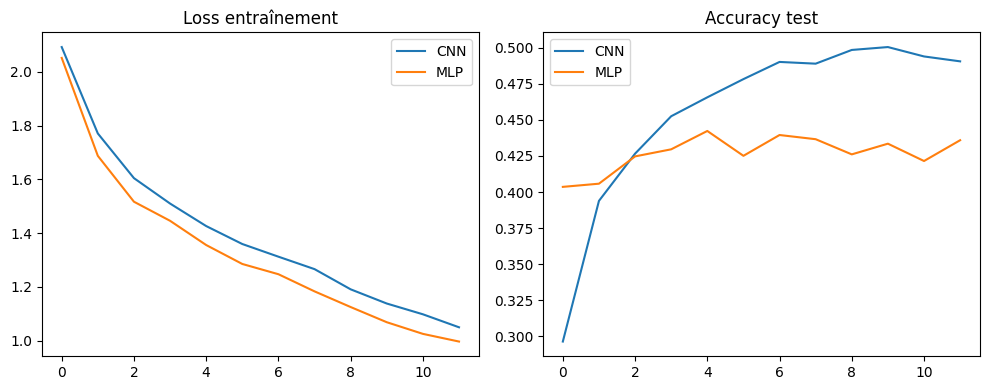

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_cnn["loss"], label="CNN")
plt.plot(hist_mlp["loss"], label="MLP")
plt.title("Loss entraînement")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_cnn["acc"], label="CNN")
plt.plot(hist_mlp["acc"], label="MLP")
plt.title("Accuracy test")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Expériences – padding, stride, pooling, filtres, conv 1×1

In [9]:
def eval_config(**kwargs):
    model, hist = train_classifier(LeNetCIFAR(**kwargs), epochs=8, name=str(kwargs))
    return hist["acc"][-1]

experiments = {
    "baseline": {},
    "plus_de_filtres": {"channels": (16, 32)},
    "conv_1x1": {"channels": (6, 16), "use_1x1": True},
}
scores = {k: eval_config(**v) for k, v in experiments.items()}
for k, v in scores.items():
    print(f"{k:20s} → test accuracy = {v:.4f}")

[{}] Epoch 01 | loss=2.0464 | test_acc=0.3296


[{}] Epoch 02 | loss=1.7455 | test_acc=0.4097


[{}] Epoch 03 | loss=1.5974 | test_acc=0.4184


[{}] Epoch 04 | loss=1.5212 | test_acc=0.4248


[{}] Epoch 05 | loss=1.4527 | test_acc=0.4635


...

[{'channels': (6, 16), 'use_1x1': True}] Epoch 04 | loss=1.5734 | test_acc=0.4245


[{'channels': (6, 16), 'use_1x1': True}] Epoch 05 | loss=1.5141 | test_acc=0.4361


[{'channels': (6, 16), 'use_1x1': True}] Epoch 06 | loss=1.4593 | test_acc=0.4563


[{'channels': (6, 16), 'use_1x1': True}] Epoch 07 | loss=1.4162 | test_acc=0.4643


[{'channels': (6, 16), 'use_1x1': True}] Epoch 08 | loss=1.3688 | test_acc=0.4733
baseline             → test accuracy = 0.5117
plus_de_filtres      → test accuracy = 0.5418
conv_1x1             → test accuracy = 0.4733


In [10]:
# Effet du stride / padding sur une conv isolée
x = torch.randn(1, 3, 32, 32)
for desc, kw in [
    ("padding=0, stride=1", dict(kernel_size=5, padding=0, stride=1)),
    ("padding=2, stride=1", dict(kernel_size=5, padding=2, stride=1)),
    ("stride=2", dict(kernel_size=5, padding=0, stride=2)),
]:
    y = F.conv2d(x, torch.randn(16, 3, 5, 5), padding=kw["padding"], stride=kw["stride"])
    print(desc, "-> sortie", tuple(y.shape))

padding=0, stride=1 -> sortie (1, 16, 28, 28)
padding=2, stride=1 -> sortie (1, 16, 32, 32)
stride=2 -> sortie (1, 16, 14, 14)


## 6. Visualisation des feature maps

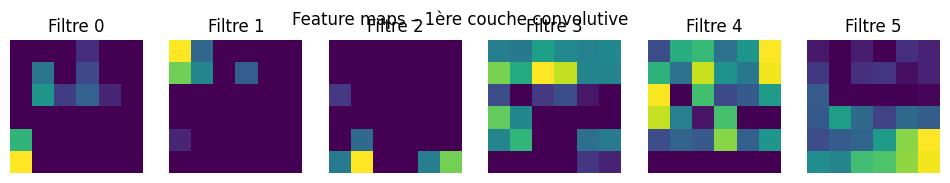

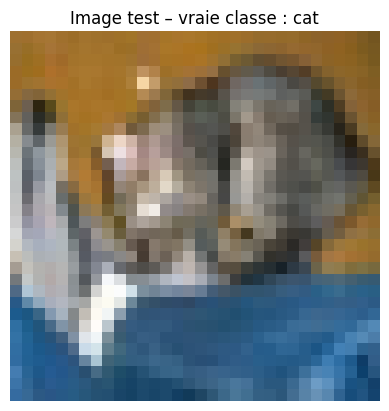

In [11]:
cnn_model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    feat = cnn_model.features(images[:1])

# Première couche : 6 filtres
fm = feat[0].cpu()
n_show = min(6, fm.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(12, 2))
for i in range(n_show):
    axes[i].imshow(fm[i].numpy(), cmap="viridis")
    axes[i].set_title(f"Filtre {i}")
    axes[i].axis("off")
plt.suptitle("Feature maps – 1ère couche convolutive")
plt.show()

# Image originale
img = images[0].cpu().permute(1, 2, 0).numpy()
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])
img = np.clip(img * std + mean, 0, 1)
plt.imshow(img)
plt.title(f"Image test – vraie classe : {classes[labels[0]]}")
plt.axis("off")
plt.show()

## 7. Question de synthèse – Partie II

**Question :** Pourquoi un CNN est-il plus pertinent qu'un MLP pour la classification d'images sur un dataset réel ?

**Pistes de réponse** (à rédiger dans le rapport avec vos courbes) :

- Le MLP traite 3072 pixels indépendamment → explosion paramétrique, pas d'exploitation de la structure 2D.
- Le CNN exploite localité et partage des poids → meilleure généralisation sur CIFAR-10.
- Padding préserve les bords ; stride réduit la résolution ; pooling apporte invariance locale ; conv 1×1 mélange canaux sans changer la résolution spatiale.
- Interpréter les feature maps : filtres bas niveau ≈ contours / textures.

## 8. Export vers l'annexe expérimentale

In [12]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from src import partie2_cnn
metrics = partie2_cnn.run(export=True, epochs=10)
print("→ annexe/partie2/")

Entraînement CNN LeNet...


  [CNN] epoch 1/10 test_acc=0.2965


  [CNN] epoch 2/10 test_acc=0.3939


  [CNN] epoch 3/10 test_acc=0.4266


  [CNN] epoch 4/10 test_acc=0.4525


...

  [conv_1x1] epoch 2/5 test_acc=0.3784


  [conv_1x1] epoch 3/5 test_acc=0.3890


  [conv_1x1] epoch 4/5 test_acc=0.4280


  [conv_1x1] epoch 5/5 test_acc=0.4445


→ annexe/partie2/
